# Grammar scoring from spoken English

SHL Hiring Assessment 2026. Each clip is a 45 to 60 second spoken answer and the label is a grammar score
from 0 to 5 given by human raters with the rubric on the competition page. The leaderboard metric is RMSE.

My approach, in short:

1. Transcribe every clip with Whisper large-v3, keeping fillers and word timings.
2. Score the transcript in two ways: fluency and complexity statistics, and rubric grades from an LLM.
3. Embed the raw audio with three speech models (WavLM, the Whisper encoder, HuBERT), pooled per
   layer, plus small attention heads trained on frame sequences.
4. Train a small model on each feature group and blend their out-of-fold predictions with a linear stacker.

The part that mattered most was not a model but the validation. The training set contains the same
speakers many times, and the test speakers are new, so an ordinary random split lets models recognise
voices instead of grammar. Section 6 shows how I found this and how the folds are built so that every
number in the notebook is measured on unseen speakers.

Heavy outputs are cached under `/kaggle/working/cache` and picked up from attached inputs when present, so
the notebook can be rerun quickly. The Groq key for the LLM grading is read from Kaggle Secrets as
`GROQ_API_KEY`; the grades themselves are cached as well.

In [1]:
!pip install -q faster-whisper==1.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 60.4 MB/s eta 0:00:00


In [2]:
import gc
import glob
import json
import math
import os
import re
import shutil
import threading
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

WORK = "/kaggle/working"
INPUT = "/kaggle/input"
CACHE = f"{WORK}/cache"
os.makedirs(CACHE, exist_ok=True)
print("GPUs:", [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])


def find(name):
    hits = glob.glob(f"{WORK}/**/{name}", recursive=True) + glob.glob(f"{INPUT}/**/{name}", recursive=True)
    if not hits:
        return None
    # copy cached files from earlier runs into this run's output, so every version carries the full cache
    if hits[0].startswith(INPUT) and "/cache" in hits[0]:
        dst = f"{CACHE}/{name}"
        if not os.path.exists(dst):
            shutil.copy(hits[0], dst)
        return dst
    return hits[0]


def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

GPUs: ['Tesla T4', 'Tesla T4']


## 1. Data

In [3]:
DATA_DIR = os.path.dirname(find("train.csv"))
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

df = pd.concat([train.assign(split="train"), test.assign(split="test", label=np.nan)], ignore_index=True)
df = df.rename(columns={"filename": "file_id"})
# train and test reuse file names (audio_19.wav is in both), so rows are keyed on split too
df["uid"] = df.split + "/" + df.file_id
df["path"] = [f"{DATA_DIR}/{u}" for u in df.uid]
assert df.uid.is_unique
df["duration"] = [sf.info(p).duration for p in df.path]

is_train = (df.split == "train").values
tr_idx, te_idx = np.where(is_train)[0], np.where(~is_train)[0]
y = df.loc[is_train, "label"].values
print(df.split.value_counts().to_dict())
print(df.loc[is_train, "label"].value_counts().sort_index().to_dict())

{'train': 769, 'test': 216}
{0.0: 37, 1.0: 1, 1.5: 3, 2.0: 102, 2.5: 79, 3.0: 174, 3.5: 64, 4.0: 124, 4.5: 52, 5.0: 133}


Score 0 is a separate cluster of 37 clips and there are almost no 1.0 or 1.5 clips, so 0 behaves like a
"not a real answer" flag rather than the bottom of a scale. Test clips are also shorter than training clips,
so every feature below is a rate per word or per minute rather than a count.

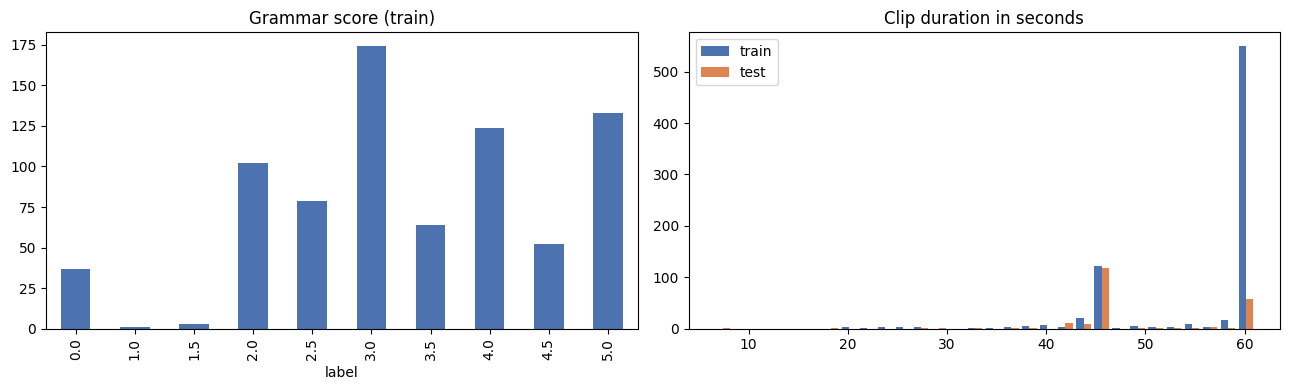

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df.loc[is_train, "label"].value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0", title="Grammar score (train)")
ax[1].hist([df.duration[is_train], df.duration[~is_train]], bins=30, label=["train", "test"], color=["#4C72B0", "#DD8452"])
ax[1].set_title("Clip duration in seconds")
ax[1].legend()
plt.tight_layout()
plt.show()

## 2. Transcription

Whisper large-v3 through faster-whisper, one model copy per GPU. The initial prompt contains fillers and a
restart so Whisper keeps them instead of cleaning the speech up. `condition_on_previous_text` is off so a
bad segment does not drag the next one down, and there is no VAD filter so pauses stay in the word timings.

In [5]:
if find("transcripts.parquet") is None:
    from faster_whisper import WhisperModel

    asr = WhisperModel("large-v3", device="cuda", device_index=[0, 1], compute_type="float16", num_workers=2)
    # fillers in the prompt stop whisper from tidying up the speech
    prompt = "Umm, so, uh, I think... I mean, like, we was going there and- and then, hmm, yeah."

    def transcribe(path):
        # pass raw samples, faster-whisper's own decoder fails on kaggle's pyav version
        audio, _ = sf.read(path, dtype="float32")
        segments, _ = asr.transcribe(audio, language="en", beam_size=5, word_timestamps=True,
                                     condition_on_previous_text=False, initial_prompt=prompt, vad_filter=False)
        segments = list(segments)
        words = [{"w": w.word, "s": round(w.start, 2), "e": round(w.end, 2), "p": round(w.probability, 3)}
                 for seg in segments for w in seg.words]
        return {
            "text": " ".join(seg.text.strip() for seg in segments),
            "avg_logprob": float(np.mean([s.avg_logprob for s in segments])) if segments else np.nan,
            "no_speech_prob": float(np.mean([s.no_speech_prob for s in segments])) if segments else np.nan,
            "words": json.dumps(words),
        }

    t0 = time.time()
    with ThreadPoolExecutor(2) as pool:
        rows = list(tqdm(pool.map(transcribe, df.path), total=len(df)))
    print(f"{(time.time() - t0) / 60:.1f} min")
    pd.DataFrame(rows).assign(file_id=df.file_id.values).to_parquet(f"{CACHE}/transcripts.parquet", index=False)
    del asr
    free_gpu()

tr = pd.read_parquet(find("transcripts.parquet"))
assert (tr.file_id.values == df.file_id.values).all()
df = pd.concat([df, tr.drop(columns="file_id")], axis=1)
df["words"] = df["words"].apply(json.loads)
df["n_words"] = df.text.str.split().str.len()

for s in sorted(df.label.dropna().unique()):
    print(f"[{s}] {df[df.label == s].text.iloc[0][:220]}\n")

[0.0] While pedaling, the wind boxed on my skin. every time I leave my home, I just make myself forget the truth so that it ever exists. into an accident such as blocking my car so that I have two keys and then go home.

[1.0] As a young child, one of the most exciting place to be was the playground. It was a place where the rules of classrooms and the structure environment of schools has been, uh, played well in our, like, the school days. We

[1.5] A crowded market often means more opportunity, not less opportunity. First, if a market crowded, it means the- that there is a pl- plenty of demand. There are loads of people who want to buy. Second, if a market is crowd

[2.0] Once upon a time, we, with five friends, went on a tour, went on a deep tour with a travel agent on a Manali, and we stayed in a resort, and we stayed around, we stayed at a resort, and after that, we stayed when we chec

[2.5] The best day of my life was probably when I won a NASS competition, and I guess why this 

## 3. Transcript features

### 3.1 Fluency and complexity statistics

Speech rate, pauses, fillers, restarts and repeats come from the word timings. Sentence length, vocabulary
range and subordinate clauses are cheap proxies for complexity. Whisper's own confidence is included too.

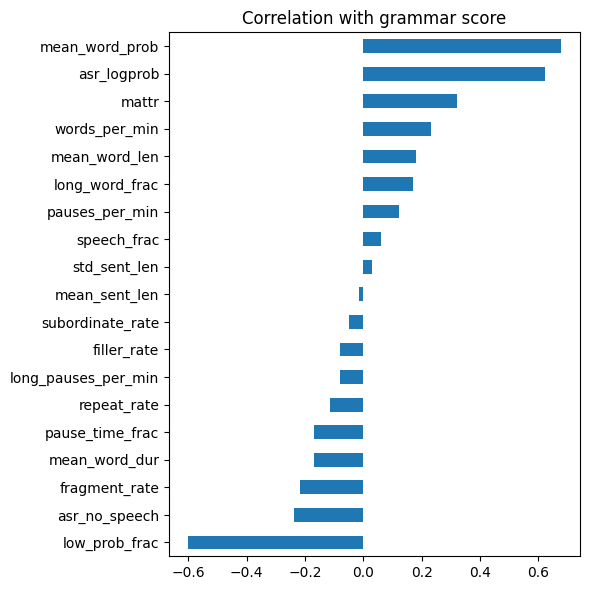

In [6]:
FILLERS = {"um", "umm", "uh", "uhm", "hmm", "mm", "er", "erm", "ah", "eh"}
SUBORDINATORS = {"because", "although", "though", "while", "whereas", "unless", "since", "which", "who",
                 "whom", "whose", "that", "when", "if", "whether", "where", "after", "before"}


def tokens(text):
    return re.findall(r"[a-z']+", text.lower())


def sentences(text):
    return [s for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s]


def mattr(toks, window=50):
    if len(toks) <= window:
        return len(set(toks)) / max(len(toks), 1)
    return np.mean([len(set(toks[i:i + window])) / window for i in range(len(toks) - window + 1)])


def fluency_features(row):
    words, toks = row.words, tokens(row.text)
    clean = [t for t in toks if t not in FILLERS]
    n = max(len(toks), 1)
    f = {}
    if len(words) > 1:
        starts = np.array([w["s"] for w in words])
        ends = np.array([w["e"] for w in words])
        span = max(ends[-1] - starts[0], 1.0)
        gaps = np.clip(starts[1:] - ends[:-1], 0, None)
        f["words_per_min"] = 60 * len(words) / span
        f["pauses_per_min"] = 60 * (gaps > 0.5).sum() / span
        f["long_pauses_per_min"] = 60 * (gaps > 1.5).sum() / span
        f["pause_time_frac"] = gaps[gaps > 0.3].sum() / span
        f["mean_word_dur"] = float(np.mean(ends - starts))
        f["speech_frac"] = span / row.duration
    probs = np.array([w["p"] for w in words]) if words else np.array([0.0])
    f["mean_word_prob"] = probs.mean()
    f["low_prob_frac"] = (probs < 0.5).mean()
    f["filler_rate"] = sum(t in FILLERS for t in toks) / n
    f["fragment_rate"] = len(re.findall(r"\b[\w']+-(?=\s|$)", row.text)) / n
    f["repeat_rate"] = sum(a == b for a, b in zip(clean, clean[1:])) / n
    sent_lens = [len(tokens(s)) for s in sentences(row.text)] or [0]
    f["mean_sent_len"] = np.mean(sent_lens)
    f["std_sent_len"] = np.std(sent_lens)
    f["mattr"] = mattr(clean)
    f["mean_word_len"] = np.mean([len(t) for t in clean]) if clean else 0
    f["long_word_frac"] = np.mean([len(t) > 6 for t in clean]) if clean else 0
    f["subordinate_rate"] = sum(t in SUBORDINATORS for t in clean) / n
    f["asr_logprob"] = row.avg_logprob
    f["asr_no_speech"] = row.no_speech_prob
    return f


fluency = pd.DataFrame([fluency_features(r) for r in df.itertuples()]).fillna(0)
fluency.corrwith(df.label).sort_values().plot.barh(figsize=(6, 6), title="Correlation with grammar score")
plt.tight_layout()
plt.show()

### 3.2 LLM grading

gpt-oss-120b on Groq grades every transcript. The prompt has the official rubric and 16 graded transcripts
from the training set, two per score level, so the model sees how these raters use the scale. A second,
disjoint set of examples is used when grading one of the example clips itself, so no clip is graded with its
own label visible. Each grade comes with an error count, severity, structural range, a coherence rating and a
corrected transcript; the words changed between transcript and correction give a direct error rate.

Spending is capped: cost is computed from the token counts of every reply, a five clip pilot runs first and
the full run only starts if it parses cleanly and the projected cost fits the budget. Grades are cached and
reused across runs.

gptoss: 947/985 graded, score correlation 0.549


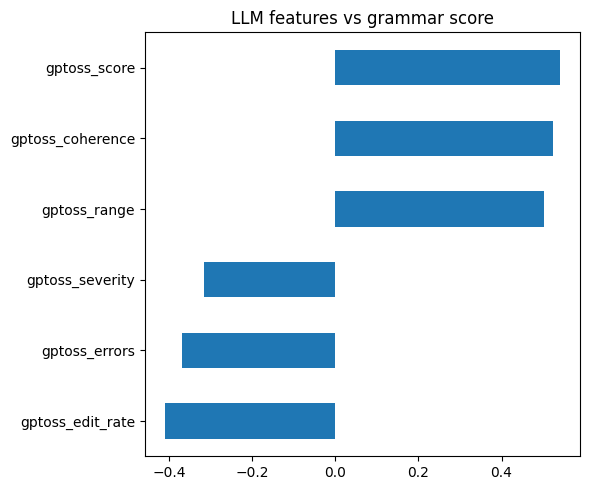

In [7]:
try:
    from kaggle_secrets import UserSecretsClient
    GROQ_KEY = UserSecretsClient().get_secret("GROQ_API_KEY")
except Exception:
    GROQ_KEY = os.environ.get("GROQ_API_KEY", "")

JUDGES = {"gptoss": "openai/gpt-oss-120b"}
PRICE_PER_M = {"openai/gpt-oss-120b": (0.15, 0.60)}
FIELDS = ["score", "errors", "severity", "range", "coherence"]
BUDGET = 0.85
RETRY_FAILED = False
spent = {"usd": 0.0}
spend_lock = threading.Lock()

RUBRIC = """1: Struggles with proper sentence structure and syntax, limited control over simple grammatical structures and memorized sentence patterns.
2: Limited understanding of sentence structure and syntax. Uses simple structures but consistently makes basic sentence structure and grammatical mistakes. May leave sentences incomplete.
3: Decent grasp of sentence structure but makes errors in grammatical structure, or decent grasp of grammatical structure but errors in sentence syntax and structure.
4: Strong understanding of sentence structure and syntax. Consistently good control of grammar. Occasional minor errors that do not cause misunderstanding, and can correct most of them.
5: High grammatical accuracy and adept control of complex grammar. Uses grammar accurately and effectively, seldom makes noticeable mistakes, handles complex structures well and self-corrects when necessary."""

INSTRUCTIONS = """You grade spoken English for grammar. The text is an automatic transcript of a candidate speaking for about a minute. Fillers (um, uh), repetitions and restarts are normal in speech and are not grammar errors. Ignore punctuation and capitalisation, the transcriber adds them. Judge grammar only: sentence structure, syntax, verb forms, agreement, articles, prepositions, tense, word order, and the range of structures used.

Rubric
{rubric}
Half steps are allowed (1.0, 1.5, ... 5.0). Use 0 only when the recording is not a genuine attempt at the task: unintelligible, random disconnected sentences, or clearly not spontaneous speech.

Graded examples
{examples}

Reply with only a JSON object with these keys:
"corrected": the transcript rewritten with the grammar fixed, keeping the original wording as far as possible, fillers and repetitions removed
"errors": number of distinct grammar errors in the transcript
"severity": how much the errors hurt understanding, 1 (not at all) to 5 (severely)
"range": variety and complexity of grammatical structures used, 1 to 5
"coherence": how much it reads like a genuine connected answer, 1 to 5
"score": the rubric score"""


def pick_anchors():
    pool = df[is_train & df.n_words.between(70, 130)]
    rng = np.random.default_rng(SEED)
    sets = {"A": [], "B": []}
    for level in [0, 2, 2.5, 3, 3.5, 4, 4.5, 5]:
        ids = rng.permutation(pool[pool.label == level].index)[:4]
        sets["A"] += list(ids[:2])
        sets["B"] += list(ids[2:])
    return sets


ANCHORS = pick_anchors()


def system_prompt(anchor_ids):
    rows = df.loc[anchor_ids].sample(frac=1, random_state=SEED)
    examples = "\n".join(f"[score {r.label:.1f}] {r.text}" for r in rows.itertuples())
    return INSTRUCTIONS.format(rubric=RUBRIC, examples=examples)


PROMPTS = {k: system_prompt(v) for k, v in ANCHORS.items()}


def parse(content):
    out = json.loads(re.search(r"\{.*\}", content, re.S).group())
    return {"corrected": str(out["corrected"]), **{k: float(out[k]) for k in FIELDS}}


def cost(model, usage):
    p_in, p_out = PRICE_PER_M[model]
    return (usage.get("prompt_tokens", 0) * p_in + usage.get("completion_tokens", 0) * p_out) / 1e6


def ask(model, text, prompt):
    body = {
        "model": model,
        "temperature": 0,
        "max_completion_tokens": 4000,
        "reasoning_effort": "low",
        "messages": [{"role": "system", "content": prompt}, {"role": "user", "content": "Transcript:\n" + text}],
    }
    for attempt in range(10):
        if spent["usd"] > BUDGET:
            raise RuntimeError(f"budget of ${BUDGET} reached")
        try:
            r = requests.post("https://api.groq.com/openai/v1/chat/completions", json=body, timeout=120,
                              headers={"Authorization": f"Bearer {GROQ_KEY}"})
        except requests.RequestException:
            time.sleep(2 ** min(attempt, 5))
            continue
        if r.status_code in (401, 402, 403):
            raise RuntimeError(f"Groq {r.status_code}: {r.text[:300]}")
        if r.status_code == 429 or r.status_code >= 500:
            time.sleep(float(r.headers.get("retry-after", 2 ** min(attempt, 5))))
            continue
        d = r.json()
        with spend_lock:
            spent["usd"] += cost(model, d.get("usage", {}))
        content = (d.get("choices") or [{}])[0].get("message", {}).get("content") or ""
        try:
            return parse(content), content
        except Exception:
            return None, content or json.dumps(d)[:500]
    return None, "network or rate limit"


def run_judge(name, model):
    path, raw_path = f"{CACHE}/judge_{name}.jsonl", f"{CACHE}/judge_{name}_raw.jsonl"
    for p in (path, raw_path):
        hits = glob.glob(f"{INPUT}/**/{os.path.basename(p)}", recursive=True)
        if hits and not os.path.exists(p):
            shutil.copy(max(hits, key=os.path.getsize), p)
    done = {}
    if os.path.exists(path):
        for line in open(path):
            if line.strip():
                rec = json.loads(line)
                done[rec["uid"]] = rec
    lock = threading.Lock()

    def work(i):
        row = df.iloc[i]
        prompt = PROMPTS["B"] if i in ANCHORS["A"] else PROMPTS["A"]
        out, raw = ask(model, row.text, prompt)
        with lock:
            with open(raw_path, "a") as f:
                f.write(json.dumps({"uid": row.uid, "raw": raw}) + "\n")
            if out is not None:
                rec = {"uid": row.uid, **out}
                with open(path, "a") as f:
                    f.write(json.dumps(rec) + "\n")
                done[row.uid] = rec
        return out is not None, raw

    todo = [i for i in range(len(df)) if df.uid[i] not in done]
    if done and not RETRY_FAILED:
        # grades from an earlier run are reused as they are, no new api calls
        todo = []
    if todo and len(done) < 5:
        before = spent["usd"]
        pilot = [work(i) for i in todo[:5]]
        todo = todo[5:]
        projected = spent["usd"] + (spent["usd"] - before) / 5 * len(todo)
        print(f"{name} pilot: {sum(ok for ok, _ in pilot)}/5 parsed, projected total ${projected:.3f}")
        if sum(ok for ok, _ in pilot) < 4:
            raise RuntimeError(f"{name} pilot failed, first reply: {pilot[0][1][:500]}")
        if projected > BUDGET:
            raise RuntimeError(f"projected cost ${projected:.3f} is over the ${BUDGET} budget")
    if todo:
        with ThreadPoolExecutor(3) as pool:
            ok = list(tqdm(pool.map(lambda i: work(i)[0], todo), total=len(todo), desc=name))
        print(f"{name}: {sum(ok)}/{len(todo)} parsed, ${spent['usd']:.3f} spent so far")
    return pd.DataFrame([done.get(u, {"uid": u}) for u in df.uid]).reindex(columns=["uid", "corrected"] + FIELDS)


def edit_rate(src, fix):
    # drop fillers first so removing them doesn't count as a correction
    a, b = tokens(re.sub(r"\b(" + "|".join(FILLERS) + r")\b", "", src)), tokens(fix)
    ops = [op for op in SequenceMatcher(None, a, b, autojunk=False).get_opcodes() if op[0] != "equal"]
    return sum(max(i2 - i1, j2 - j1) for _, i1, i2, j1, j2 in ops) / max(len(a), 1)


judge = pd.DataFrame(index=df.index)
for name, model in JUDGES.items():
    out = run_judge(name, model)
    for k in FIELDS:
        judge[f"{name}_{k}"] = out[k].values
    judge[f"{name}_errors"] = 100 * judge[f"{name}_errors"] / df.n_words.clip(lower=1)
    judge[f"{name}_edit_rate"] = [edit_rate(s, f) if isinstance(f, str) else np.nan for s, f in zip(df.text, out.corrected)]
    print(f"{name}: {out.score.notna().sum()}/{len(df)} graded, score correlation {out.score.corr(df.label):.3f}")

judge = judge.fillna(judge.median())
judge.corrwith(df.label).sort_values().plot.barh(figsize=(6, 5), title="LLM features vs grammar score")
plt.tight_layout()
plt.show()

## 4. Audio features

Three speech models read the raw waveform: WavLM-large, the Whisper large-v3 encoder and HuBERT-large.
Every layer is pooled over time by mean and std. For a few layers of WavLM, Whisper and HuBERT the
frame sequence itself is kept (averaged in blocks of 8 frames, about 160 ms) for the attention heads in
section 7. Whisper reads 30 second windows, so longer clips are split and the windows concatenated.

In [8]:
DS, MAXT = 8, 400
FRAME_LAYERS = {"hubert": [18], "wavlm": [18], "whisper": [28, 31]}
need_frames = any(find(f"head_{tag}{l}_oof.npy") is None for tag, ls in FRAME_LAYERS.items() for l in ls)


def pool_and_frames(hs, keep_layers):
    means = torch.stack([h[0].float().mean(0) for h in hs]).cpu().numpy()
    stds = torch.stack([h[0].float().std(0) for h in hs]).cpu().numpy()
    frames = {}
    for l in keep_layers:
        x = hs[l][0].float()
        T = (x.shape[0] // DS) * DS
        f = x[:T].reshape(T // DS, DS, -1).mean(1) if T >= DS else x.mean(0, keepdim=True)
        frames[l] = f[:MAXT].half().cpu().numpy()
    return means, stds, frames


def run_wavlm_like(model_id, cls, keep_layers, tag):
    from transformers import AutoFeatureExtractor, Wav2Vec2FeatureExtractor
    try:
        fe = AutoFeatureExtractor.from_pretrained(model_id)
    except Exception:
        fe = Wav2Vec2FeatureExtractor(sampling_rate=16000, do_normalize=True)
    model = cls.from_pretrained(model_id).to("cuda").eval()
    means, stds, frames = [], [], {l: [] for l in keep_layers}
    for path in tqdm(df.path, desc=tag):
        audio, _ = sf.read(path, dtype="float32")
        x = fe(audio, sampling_rate=16000, return_tensors="pt").input_values.to("cuda")
        with torch.no_grad():
            hs = model(x, output_hidden_states=True).hidden_states
        m, s, fr = pool_and_frames(hs, keep_layers)
        means.append(m)
        stds.append(s)
        for l in keep_layers:
            frames[l].append(fr[l])
    np.save(f"{CACHE}/{tag}_mean.npy", np.stack(means).astype(np.float16))
    np.save(f"{CACHE}/{tag}_std.npy", np.stack(stds).astype(np.float16))
    del model
    free_gpu()
    return frames


def run_whisper(keep_layers, tag="whisper"):
    from transformers import WhisperFeatureExtractor, WhisperModel
    wfe = WhisperFeatureExtractor.from_pretrained("openai/whisper-large-v3")
    enc = WhisperModel.from_pretrained("openai/whisper-large-v3").encoder.half().cuda().eval()
    window = 30 * 16000
    means, stds, frames = [], [], {l: [] for l in keep_layers}
    for path in tqdm(df.path, desc=tag):
        audio, _ = sf.read(path, dtype="float32")
        parts = []
        for start in range(0, len(audio), window):
            chunk = audio[start:start + window]
            # the encoder outputs 50 frames per second, the rest of the 30 s window is padding
            n = max(1, int(len(chunk) / 16000 * 50))
            x = wfe(chunk, sampling_rate=16000, return_tensors="pt").input_features.half().cuda()
            with torch.no_grad():
                hs = enc(x, output_hidden_states=True).hidden_states
            parts.append([h[0, :n].float().cpu() for h in hs])
        hs = [torch.cat([p[l] for p in parts]).unsqueeze(0) for l in range(len(parts[0]))]
        m, s, fr = pool_and_frames(hs, keep_layers)
        means.append(m)
        stds.append(s)
        for l in keep_layers:
            frames[l].append(fr[l])
    np.save(f"{CACHE}/{tag}_mean.npy", np.stack(means).astype(np.float16))
    np.save(f"{CACHE}/{tag}_std.npy", np.stack(stds).astype(np.float16))
    del enc
    free_gpu()
    return frames


from transformers import HubertModel, WavLMModel

frames = {}
runners = {
    "wavlm": lambda ls: run_wavlm_like("microsoft/wavlm-large", WavLMModel, ls, "wavlm"),
    "whisper": lambda ls: run_whisper(ls),
    "hubert": lambda ls: run_wavlm_like("facebook/hubert-large-ll60k", HubertModel, ls, "hubert"),
}
for tag, run in runners.items():
    cached = find(f"{tag}_mean.npy") is not None and find(f"{tag}_std.npy") is not None
    if not cached or (need_frames and tag in FRAME_LAYERS):
        fr = run(FRAME_LAYERS.get(tag, []))
        frames.update({(tag, l): v for l, v in fr.items()})

A = {}
for tag in runners:
    A[f"{tag}_mean"] = np.load(find(f"{tag}_mean.npy")).astype(np.float32)
    A[f"{tag}_std"] = np.load(find(f"{tag}_std.npy")).astype(np.float32)
print({k: v.shape for k, v in A.items()})

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

hubert:   0%|          | 0/985 [00:00<?, ?it/s]

{'wavlm_mean': (985, 25, 1024), 'wavlm_std': (985, 25, 1024), 'whisper_mean': (985, 33, 1280), 'whisper_std': (985, 33, 1280), 'hubert_mean': (985, 25, 1024), 'hubert_std': (985, 25, 1024)}


## 5. Speakers, and why the folds matter

A first version of this notebook used ordinary stratified 5-fold cross validation and scored around 0.51
RMSE on it, with an SVR on audio embeddings as the strongest model. On the leaderboard the same model did
fine, but a kNN on the embeddings and the SVR were suspiciously strong in validation, so I checked what the
audio embeddings were actually matching.

Nearest neighbours by cosine similarity on an early WavLM layer (layer 6, which carries voice and channel
information rather than content) share the exact label 55% of the time, against 15% for random pairs. The
training set has the same speakers many times. Linking clips with similarity above 0.95 gives 413 speaker
groups for 769 clips, and within a group the label barely moves (std 0.17 against 1.24 overall). The 37
zero-score clips form one such group.

The test clips are different speakers: their similarity to the nearest training clip matches the
"nearest other speaker" distribution at every layer, not the "same speaker" one. So a random split rewards
memorising voices, and the honest validation is a group split by speaker. All results below use it. The
zero-score group is kept out of training, since the test set has no clip that resembles it.

speaker groups: 413, clips in groups of 2+: 549, largest group: 37
within-speaker label std: 0.167  overall: 1.238
nearest neighbour has the same label: 0.54   random pair: 0.15


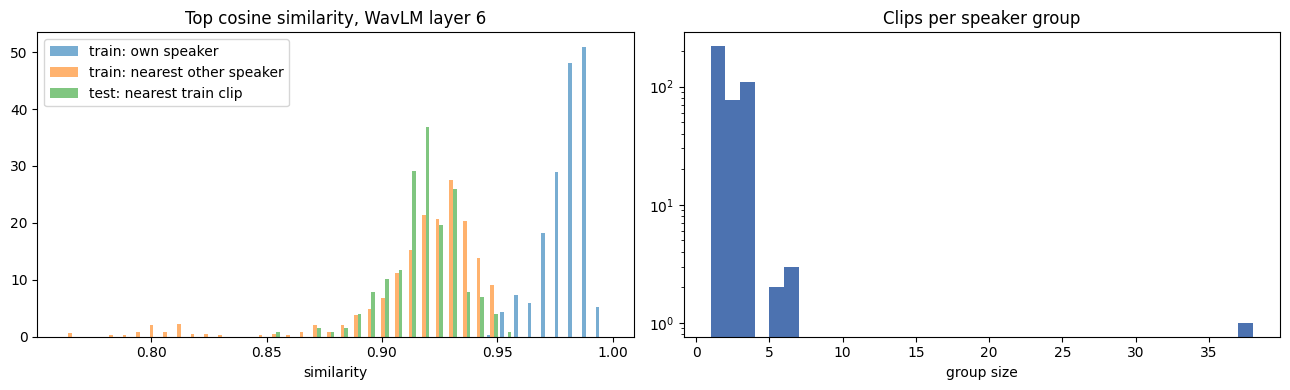

zero-score clips in one group: 37/37; test clips similar to it: 0


In [9]:
Z6 = normalize(A["wavlm_mean"][:, 6])
S = Z6[tr_idx] @ Z6[tr_idx].T
np.fill_diagonal(S, 0)
_, groups = connected_components(S > 0.95, directed=False)
sizes = np.bincount(groups)
print(f"speaker groups: {groups.max() + 1}, clips in groups of 2+: {(sizes[groups] > 1).sum()}, largest group: {sizes.max()}")

same = groups[:, None] == groups[None, :]
within = np.where(same, S, -1).max(1)
cross = np.where(~same, S, -1).max(1)
test_to_train = (Z6[te_idx] @ Z6[tr_idx].T).max(1)
multi = sizes[groups] > 1
print(f"within-speaker label std: {np.mean([y[groups == g].std() for g in np.where(sizes > 1)[0]]):.3f}  overall: {y.std():.3f}")

nn_label = y[np.argmax(S, 1)]
rng = np.random.default_rng(0)
print(f"nearest neighbour has the same label: {(nn_label == y).mean():.2f}   random pair: {(y[rng.permutation(len(y))] == y).mean():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist([within[multi], cross, test_to_train], bins=40, density=True, label=["train: own speaker", "train: nearest other speaker", "test: nearest train clip"], alpha=0.6)
ax[0].set(title="Top cosine similarity, WavLM layer 6", xlabel="similarity")
ax[0].legend()
ax[1].hist(sizes, bins=range(1, sizes.max() + 2), color="#4C72B0")
ax[1].set(title="Clips per speaker group", xlabel="group size", yscale="log")
plt.tight_layout()
plt.show()

zero_group = np.bincount(groups[y == 0]).argmax()
print(f"zero-score clips in one group: {(groups[y == 0] == zero_group).sum()}/{(y == 0).sum()}; "
      f"test clips similar to it: {((Z6[te_idx] @ Z6[tr_idx][groups == zero_group].T).max(1) > 0.95).sum()}")

nz = y > 0
ynz = y[nz]
strata = (ynz * 2).astype(int)
nz_idx = tr_idx[nz]


def gfolds(seed):
    return list(StratifiedGroupKFold(5, shuffle=True, random_state=seed).split(np.zeros(nz.sum()), strata, groups[nz]))

## 6. Attention heads on frame sequences

Mean pooling throws away how the speech unfolds. For a few layers a small head is trained on the frame
sequence: layer norm, learned attention over frames plus mean and std pooling, then a two layer MLP. Trained
on the non-zero clips with the speaker folds and three seeds; the out-of-fold predictions go into the stack.

In [10]:
MU, SD = ynz.mean(), ynz.std()


class Head(nn.Module):
    def __init__(self, d, h=192, p=0.3):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.att = nn.Sequential(nn.Linear(d, 128), nn.Tanh(), nn.Linear(128, 1))
        self.mlp = nn.Sequential(nn.Dropout(p), nn.Linear(3 * d, h), nn.GELU(), nn.Dropout(p), nn.Linear(h, 1))

    def forward(self, x, mask):
        x = self.norm(x)
        a = self.att(x).squeeze(-1).masked_fill(~mask, -1e4).softmax(1)
        att = (a.unsqueeze(-1) * x).sum(1)
        m = mask.unsqueeze(-1).float()
        n = m.sum(1).clamp(min=1)
        mean = (x * m).sum(1) / n
        std = (((x - mean.unsqueeze(1)) ** 2 * m).sum(1) / n).clamp(min=1e-6).sqrt()
        return self.mlp(torch.cat([att, mean, std], -1)).squeeze(-1)


def pad(seqs):
    T = max(s.shape[0] for s in seqs)
    X = np.zeros((len(seqs), T, seqs[0].shape[1]), np.float16)
    M = np.zeros((len(seqs), T), bool)
    for i, s in enumerate(seqs):
        X[i, :s.shape[0]] = s
        M[i, :s.shape[0]] = True
    return torch.tensor(X), torch.tensor(M)


def train_head(X, M, t, fit, val, seed, epochs=40, bs=32, lr=1e-3):
    torch.manual_seed(seed)
    model = Head(X.shape[-1]).cuda()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * int(np.ceil(len(fit) / bs)))
    best, best_state, bad = np.inf, None, 0
    for ep in range(epochs):
        model.train()
        order = np.random.RandomState(seed * 100 + ep).permutation(fit)
        for i in range(0, len(order), bs):
            b = order[i:i + bs]
            xb, mb = X[b].cuda().float(), M[b].cuda()
            xb = xb + 0.1 * torch.randn_like(xb) * xb.std()
            loss = F.mse_loss(model(xb, mb), t[b].cuda())
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
        model.eval()
        with torch.no_grad():
            pv = torch.cat([model(X[val[i:i + 64]].cuda().float(), M[val[i:i + 64]].cuda()) for i in range(0, len(val), 64)])
        r = F.mse_loss(pv, t[val].cuda()).sqrt().item()
        if r < best - 1e-4:
            best, bad = r, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= 10:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model


def predict_head(model, X, M, idx):
    with torch.no_grad():
        return torch.cat([model(X[idx[i:i + 64]].cuda().float(), M[idx[i:i + 64]].cuda()) for i in range(0, len(idx), 64)]).cpu().numpy()


oofs, tests = {}, {}
for tag, ls in FRAME_LAYERS.items():
    for l in ls:
        name = f"head_{tag}{l}"
        if find(f"{name}_oof.npy") is None:
            X, M = pad(frames[(tag, l)])
            t = torch.tensor(((df.label.fillna(MU).values - MU) / SD).astype(np.float32))
            oof, te = np.zeros(nz.sum()), np.zeros(len(te_idx))
            for seed in (0, 1, 2):
                for fit, val in gfolds(seed):
                    model = train_head(X, M, t, nz_idx[fit], nz_idx[val], seed)
                    oof[val] += predict_head(model, X, M, nz_idx[val]) / 3
                    te += predict_head(model, X, M, te_idx) / 15
            np.save(f"{CACHE}/{name}_oof.npy", oof * SD + MU)
            np.save(f"{CACHE}/{name}_test.npy", te * SD + MU)
        oofs[name], tests[name] = np.load(find(f"{name}_oof.npy")), np.load(find(f"{name}_test.npy"))
        print(f"{name:16s} speaker-fold RMSE {rmse(ynz, oofs[name]):.4f}  r {pearsonr(ynz, oofs[name])[0]:.3f}")
del frames
gc.collect()

head_hubert18    speaker-fold RMSE 0.6282  r 0.789
head_wavlm18     speaker-fold RMSE 0.5822  r 0.821
head_whisper28   speaker-fold RMSE 0.6211  r 0.800
head_whisper31   speaker-fold RMSE 0.5786  r 0.824


12703

## 7. Base models

One small model per feature group, each evaluated with the speaker folds over five seeds. The layer choices
come from a scan of every layer under the same folds: WavLM layers 17 to 20 and the top Whisper layers carry
the most speaker-independent signal. Ridge is the workhorse and kernel ridge adds a little non-linearity.
The set below is what survived the experiments: I tried several more layers, an SVR and XLS-R features, and
the stacker gave them zero weight, so they are left out. All out-of-fold predictions go to the stacker.

In [11]:
X_tab = pd.concat([fluency, judge], axis=1).values.astype(np.float32)
X_llm = judge.values.astype(np.float32)
W, WH, HB = A["wavlm_mean"], A["whisper_mean"], A["hubert_mean"]


def gcv(make_model, X, seeds=(0, 1, 2, 3, 4)):
    Xnz, Xte = X[is_train][nz], X[~is_train]
    oof, te = np.zeros(nz.sum()), np.zeros(len(Xte))
    for seed in seeds:
        for fit, val in gfolds(seed):
            m = make_model().fit(Xnz[fit], ynz[fit])
            oof[val] += m.predict(Xnz[val]) / len(seeds)
            te += m.predict(Xte) / (5 * len(seeds))
    return oof, te


ridge = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 6, 30)))
krr = lambda g: (lambda: make_pipeline(StandardScaler(), KernelRidge(alpha=0.3, kernel="rbf", gamma=g)))
base = {
    "ridge_wavlm18": (ridge, W[:, 18]),
    "ridge_wavlm_all": (ridge, W.reshape(len(W), -1)),
    "ridge_wavlm_std19": (ridge, A["wavlm_std"][:, 19]),
    "krr_wavlm18": (krr(1.0 / 1024), W[:, 18]),
    "ridge_whisper25": (ridge, WH[:, 25]),
    "krr_whisper31": (krr(0.3 / 1280), WH[:, 31]),
    "ridge_whisper_std32": (ridge, A["whisper_std"][:, 32]),
    "ridge_hubert22": (ridge, HB[:, 22]),
    "ridge_hubert22_meanstd": (ridge, np.hstack([HB[:, 22], A["hubert_std"][:, 22]])),
    "ridge_features": (ridge, X_tab),
    "ridge_llm": (ridge, X_llm),
}
for name, (mk, X) in base.items():
    oofs[name], tests[name] = gcv(mk, X)
    print(f"{name:20s} speaker-fold RMSE {rmse(ynz, oofs[name]):.4f}  r {pearsonr(ynz, oofs[name])[0]:.3f}")

ridge_wavlm18        speaker-fold RMSE 0.5853  r 0.817
ridge_wavlm_all      speaker-fold RMSE 0.5915  r 0.813
ridge_wavlm_std19    speaker-fold RMSE 0.5955  r 0.810
krr_wavlm18          speaker-fold RMSE 0.7340  r 0.729
ridge_whisper25      speaker-fold RMSE 0.6075  r 0.801
krr_whisper31        speaker-fold RMSE 0.5744  r 0.825
ridge_whisper_std32  speaker-fold RMSE 0.5890  r 0.815
ridge_hubert22       speaker-fold RMSE 0.6119  r 0.797
ridge_hubert22_meanstd speaker-fold RMSE 0.6009  r 0.805
ridge_features       speaker-fold RMSE 0.7187  r 0.706
ridge_llm            speaker-fold RMSE 0.8113  r 0.600


## 8. Stacking

A linear regression with non-negative weights on the out-of-fold predictions. Non-negative weights mean it
can only blend models, not play them against each other, which matters with 732 training clips. Its own
score is measured with a second speaker split so the ensemble number is not inflated.

In [12]:
names = list(oofs)
S_tr = np.column_stack([oofs[n] for n in names])
S_te = np.column_stack([tests[n] for n in names])

stack_oof = np.zeros(nz.sum())
scores = []
for seed in (42, 7, 11, 23, 99):
    pred = np.zeros(nz.sum())
    for fit, val in gfolds(seed):
        pred[val] = LinearRegression(positive=True).fit(S_tr[fit], ynz[fit]).predict(S_tr[val])
    pred = np.clip(pred, 0, 5)
    scores.append(rmse(ynz, pred))
    stack_oof += pred / 5
stacker = LinearRegression(positive=True).fit(S_tr, ynz)
final_test = np.clip(stacker.predict(S_te), 0, 5)

results = pd.DataFrame([(n, rmse(ynz, oofs[n]), pearsonr(ynz, oofs[n])[0]) for n in names] + [("ensemble", np.mean(scores), pearsonr(ynz, stack_oof)[0])],
                       columns=["model", "cv_rmse", "cv_pearson"]).set_index("model")
print(results.round(4))
print("\nweights:", {n: w for n, w in zip(names, stacker.coef_.round(3)) if w > 0}, "intercept:", round(stacker.intercept_, 3))

                        cv_rmse  cv_pearson
model                                      
head_hubert18            0.6282      0.7893
head_wavlm18             0.5822      0.8207
head_whisper28           0.6211      0.8001
head_whisper31           0.5786      0.8244
ridge_wavlm18            0.5853      0.8166
ridge_wavlm_all          0.5915      0.8125
ridge_wavlm_std19        0.5955      0.8102
krr_wavlm18              0.7340      0.7292
ridge_whisper25          0.6075      0.8015
krr_whisper31            0.5744      0.8245
ridge_whisper_std32      0.5890      0.8148
ridge_hubert22           0.6119      0.7974
ridge_hubert22_meanstd   0.6009      0.8054
ridge_features           0.7187      0.7055
ridge_llm                0.8113      0.5995
ensemble                 0.5410      0.8465

weights: {'head_hubert18': np.float64(0.025), 'head_wavlm18': np.float64(0.115), 'head_whisper28': np.float64(0.134), 'head_whisper31': np.float64(0.012), 'ridge_wavlm18': np.float64(0.034), 'ridge_wavlm_all

## 9. Results

Training RMSE is reported two ways. The cross-validated number is measured on speakers the models never
saw and is what I expect on new data. The in-sample number comes from refitting the base models on all 732
non-zero clips and scoring those same clips; the gap between the two is the amount of overfitting.

In [13]:
# base models are refit on all non-zero clips; the heads keep their out-of-fold predictions
refit = {n: mk().fit(X[is_train][nz], ynz).predict(X[is_train][nz]) for n, (mk, X) in base.items()}
train_pred = np.clip(stacker.predict(np.column_stack([refit.get(n, oofs[n]) for n in names])), 0, 5)
print(f"Training RMSE, in-sample:          {rmse(ynz, train_pred):.4f}   Pearson {pearsonr(ynz, train_pred)[0]:.4f}")
print(f"Training RMSE, speaker-fold OOF:   {np.mean(scores):.4f}   Pearson {pearsonr(ynz, stack_oof)[0]:.4f}")

Training RMSE, in-sample:          0.3884   Pearson 0.9252
Training RMSE, speaker-fold OOF:   0.5410   Pearson 0.8465


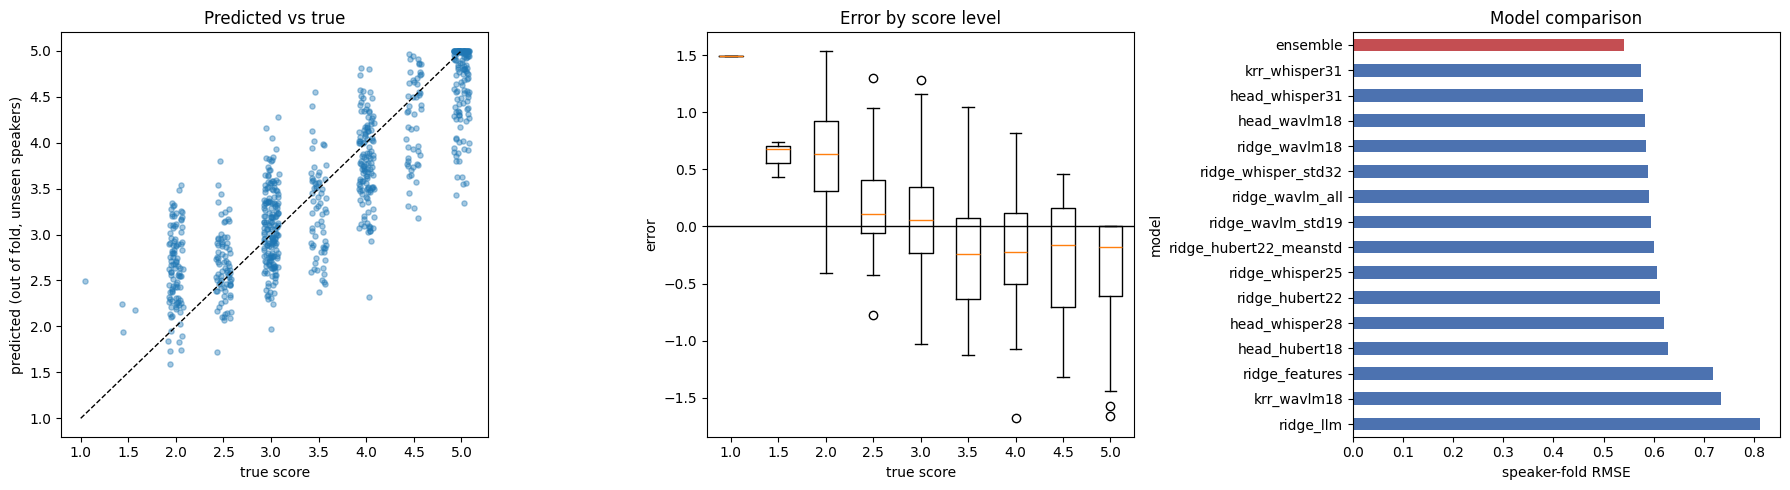

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].scatter(ynz + np.random.uniform(-0.08, 0.08, len(ynz)), stack_oof, alpha=0.4, s=14)
ax[0].plot([1, 5], [1, 5], "k--", lw=1)
ax[0].set(xlabel="true score", ylabel="predicted (out of fold, unseen speakers)", title="Predicted vs true")

levels = sorted(np.unique(ynz))
ax[1].boxplot([stack_oof[ynz == l] - l for l in levels], labels=[str(l) for l in levels])
ax[1].axhline(0, color="k", lw=1)
ax[1].set(xlabel="true score", ylabel="error", title="Error by score level")

results.cv_rmse.sort_values(ascending=False).plot.barh(ax=ax[2], color=["#C44E52" if n == "ensemble" else "#4C72B0" for n in results.cv_rmse.sort_values(ascending=False).index])
ax[2].set(xlabel="speaker-fold RMSE", title="Model comparison")
plt.tight_layout()
plt.show()

## 10. Submission

`sample_submission.csv` only shows the format, its file names are not the test clips. The submission uses the
names from `test.csv`, which match the audio in the test folder.

In [15]:
sub = pd.DataFrame({"filename": df.file_id[~is_train].values, "label": final_test})
assert list(sub.filename) == list(test.filename) and sub.label.notna().all()
assert list(sub.columns) == list(sample_sub.columns)
sub.to_csv(f"{WORK}/submission.csv", index=False)
print(sub.label.describe().round(3))
sub.head()

count    216.000
mean       3.311
std        0.828
min        1.679
25%        2.672
50%        3.236
75%        3.849
max        5.000
Name: label, dtype: float64


,filename,label
0,audio_128.wav,2.944225
1,audio_156.wav,4.384115
2,audio_19.wav,4.660247
3,audio_108.wav,1.980225
4,audio_206.wav,2.160129


## 11. Report

**Pipeline.** Whisper large-v3 transcripts (fillers kept) feed two text-side signals: fluency and complexity
statistics from the word timings, and rubric grades plus a corrected transcript from gpt-oss-120b. The raw
audio is embedded with WavLM-large, the Whisper large-v3 encoder and HuBERT-large, pooled per layer,
and small attention heads read the frame sequences of a few layers. Every group has its own small model
and a non-negative linear stacker blends their out-of-fold predictions.

**The validation finding.** The training set has repeat speakers with near-constant scores and the test
speakers are new. With a random split, audio models reach about 0.51 RMSE by recognising voices; with
speaker folds the same models sit around 0.57 to 0.60 and the SVR that looked best collapses to 0.90, which
is why it is not in the final set. Every
modelling decision in this notebook was made under speaker folds, and that is what improved the leaderboard:
the version built on random folds scored 0.3695, the first speaker-aware version 0.3598, and the version
with the extra audio models 0.3516.

**What worked.** The audio embeddings are the strongest signal by far; the mid-to-upper WavLM layers and the
top Whisper encoder layers generalise best to new speakers. The LLM grade is weaker alone (r about 0.6) but
adds information the audio does not have and keeps a stable weight in the stack. Combining different speech
models helps a little; combining different views of the same model (mean, std, all layers) helps less.

**What did not work.** A fine-tuned DeBERTa on the transcripts, a fine-tuned WavLM on the scores (too few
speakers to train on, 0.64 RMSE and weight 0 in the stack), snapping predictions to the 0.5 grid, and
recalibrating predictions to the leaderboard's mean and spread, which made things worse.

**Things that cost time.** `sample_submission.csv` lists different file names from `test.csv`, and train and
test share file names, so rows are keyed on split plus file name throughout.

**Next steps.** More training speakers would help more than any model change. With the current data, the
most promising direction is a speaker-adversarial objective on the audio side, so the embedding keeps
proficiency information and drops speaker identity explicitly.